<a href="https://colab.research.google.com/github/ryadavnitb/Batch-7/blob/Mohd_Abuzar/Infosys_Internship_Visual_Exploration_%26_Delay_Trends.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Milestone 2: Visual Exploration and Delay Trends**

**Week 3:** Univariate and Bivariate Visual Analysis
* Top airlines, routes, and busiest months
* Flight distribution by day, time, and airport
* Plot bar charts, histograms, boxplots, and line plots

**Week 4:** Delay Analysis – Airline and Weather
* Compare delay causes by airline
* Explore carrier delays, weather delays, NAS delays
* Visualize delays by time of day and airport

**Deliverables:**
* Set of visualizations (minimum 8)
* Observations on peak delays and top delay-prone carriers

#**Week 3:** Univariate and Bivariate Visual Analysis
* Top airlines, routes, and busiest months
* Flight distribution by day, time, and airport
* Plot bar charts, histograms, boxplots, and line plots

## Step 1: Importing required libraries.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set plot style for better aesthetics
sns.set(style='whitegrid')
pd.set_option('display.max_columns', None)

## Step 2: Loading Dataset.

In [2]:
print("Importing Flights dataset...")
try:
  df = pd.read_parquet('/content/drive/MyDrive/Infosys_Springboard_Dataset/Preprocessed dataset/preprocessed_flights.parquet')
  print("Successfully imported Flights dataset!")
except Exception as e:
  print(f"Error importing dataset: {e}")

Importing Flights dataset...
Successfully imported Flights dataset!


In [3]:
df.head()

,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,DEPARTURE_TIME,DEPARTURE_DELAY,TAXI_OUT,WHEELS_OFF,SCHEDULED_TIME,ELAPSED_TIME,AIR_TIME,DISTANCE,WHEELS_ON,TAXI_IN,SCHEDULED_ARRIVAL,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY,AIRLINE_NAME,ORIGIN_AIRPORT_NAME,ORIGIN_CITY,ORIGIN_STATE,ORIGIN_COUNTRY,ORIGIN_LATITUDE,ORIGIN_LONGITUDE,DESTINATION_AIRPORT_NAME,DESTINATION_CITY,DESTINATION_STATE,DESTINATION_COUNTRY,DESTINATION_LATITUDE,DESTINATION_LONGITUDE,DEPARTURE_HOUR,ARRIVAL_HOUR,FLIGHT_DATE,ROUTE,DAY_OF_WEEK_NAME,IS_WEEKEND,DEPARTURE_TIME_BLOCK
0,2015,1,1,4,AS,98,N407AS,ANC,SEA,5,2354.0,-11.0,21.0,15.0,205.0,194.0,169.0,1448,404.0,4.0,430,408.0,-22.0,0,0,NA,0.0,0.0,0.0,0.0,0.0,Alaska Airlines Inc.,Ted Stevens Anchorage International Airport,Anchorage,AK,USA,61.174320,-149.996185,Seattle-Tacoma International Airport,Seattle,WA,USA,47.448978,-122.309311,0,4,2015-01-01,ANC-SEA,Thursday,False,Night
1,2015,1,1,4,AA,2336,N3KUAA,LAX,PBI,10,2.0,-8.0,12.0,14.0,280.0,279.0,263.0,2330,737.0,4.0,750,741.0,-9.0,0,0,NA,0.0,0.0,0.0,0.0,0.0,American Airlines Inc.,Los Angeles International Airport,Los Angeles,CA,USA,33.942539,-118.408073,Palm Beach International Airport,West Palm Beach,FL,USA,26.683161,-80.095589,0,7,2015-01-01,LAX-PBI,Thursday,False,Night
2,2015,1,1,4,US,840,N171US,SFO,CLT,20,18.0,-2.0,16.0,34.0,286.0,293.0,266.0,2296,800.0,11.0,806,811.0,5.0,0,0,NA,0.0,0.0,0.0,0.0,0.0,US Airways Inc.,San Francisco International Airport,San Francisco,CA,USA,37.618999,-122.374840,Charlotte Douglas International Airport,Charlotte,NC,USA,35.214008,-80.943130,0,8,2015-01-01,SFO-CLT,Thursday,False,Night
3,2015,1,1,4,AA,258,N3HYAA,LAX,MIA,20,15.0,-5.0,15.0,30.0,285.0,281.0,258.0,2342,748.0,8.0,805,756.0,-9.0,0,0,NA,0.0,0.0,0.0,0.0,0.0,American Airlines Inc.,Los Angeles International Airport,Los Angeles,CA,USA,33.942539,-118.408073,Miami International Airport,Miami,FL,USA,25.793249,-80.290558,0,8,2015-01-01,LAX-MIA,Thursday,False,Night
4,2015,1,1,4,AS,135,N527AS,SEA,ANC,25,24.0,-1.0,11.0,35.0,235.0,215.0,199.0,1448,254.0,5.0,320,259.0,-21.0,0,0,NA,0.0,0.0,0.0,0.0,0.0,Alaska Airlines Inc.,Seattle-Tacoma International Airport,Seattle,WA,USA,47.448978,-122.309311,Ted Stevens Anchorage International Airport,Anchorage,AK,USA,61.174320,-149.996185,0,3,2015-01-01,SEA-ANC,Thursday,False,Night


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5819079 entries, 0 to 5819078
Data columns (total 51 columns):
 #   Column                    Dtype         
---  ------                    -----         
 0   YEAR                      int16         
 1   MONTH                     int8          
 2   DAY                       int8          
 3   DAY_OF_WEEK               int8          
 4   AIRLINE                   category      
 5   FLIGHT_NUMBER             int16         
 6   TAIL_NUMBER               category      
 7   ORIGIN_AIRPORT            object        
 8   DESTINATION_AIRPORT       object        
 9   SCHEDULED_DEPARTURE       int16         
 10  DEPARTURE_TIME            float32       
 11  DEPARTURE_DELAY           float32       
 12  TAXI_OUT                  float32       
 13  WHEELS_OFF                float32       
 14  SCHEDULED_TIME            float32       
 15  ELAPSED_TIME              float32       
 16  AIR_TIME                  float32       
 17  DISTANCE

## Step 3:  Univariate and Bivariate Visual Analysis.

### 3.1: Top Airlines by Number of Flights.

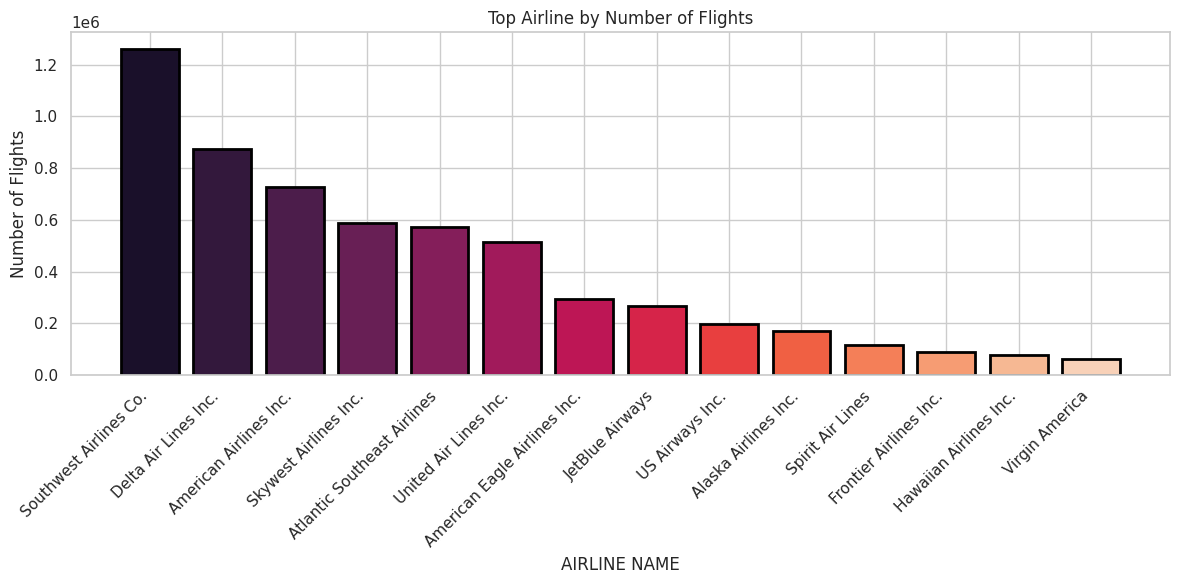

In [8]:
plt.figure(figsize=(12, 6))
# Calculate the number of flights per airline
airline_counts = df['AIRLINE_NAME'].value_counts()
color = sns.color_palette("rocket", len(airline_counts))

plt.bar(airline_counts.index, airline_counts.values, color=color, edgecolor='black', linewidth=2)
plt.title('Top Airline by Number of Flights')
plt.xlabel('AIRLINE NAME')
plt.ylabel('Number of Flights')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

 **Interpretation: Top Airlines**

This chart shows the number of flights per airline:
*   **Leaders:** Southwest, Delta, and American Airlines lead in flight volume.
*   **Mid-Tier:** Skywest, Atlantic Southeast, and United also have significant operations.
*   **Smaller:** Frontier and Allegiant operate fewer flights.

Overall, flight activity is concentrated among a few major carriers.

### 3.2: Top 20 Most Frequent Flight Routes.

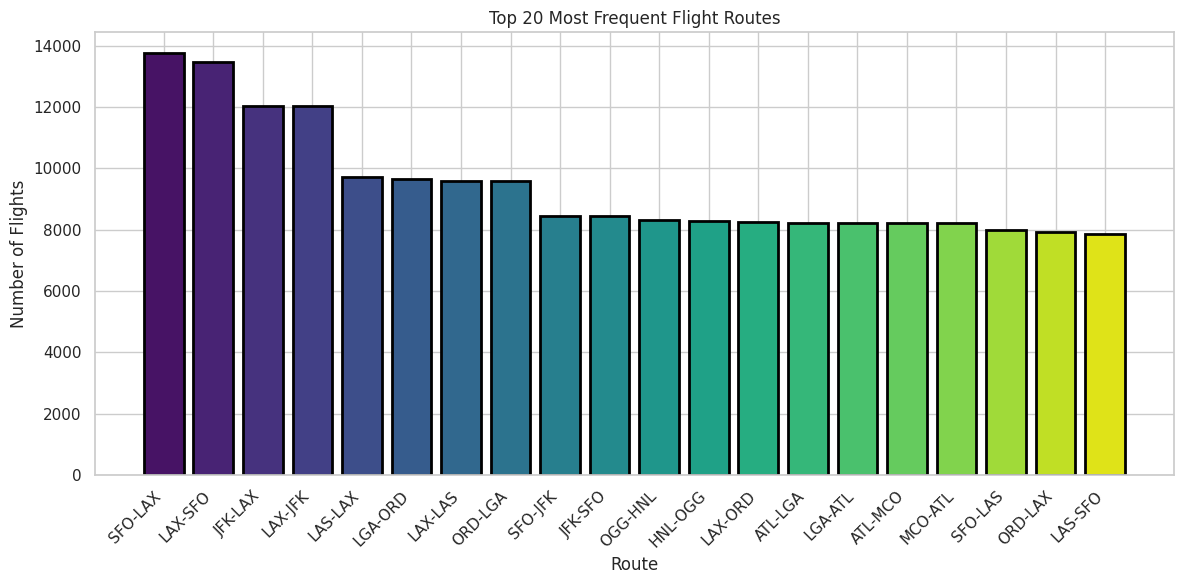

In [9]:
plt.figure(figsize=(12, 6))
# Calculate the top 20 most frequent routes
route_counts = df['ROUTE'].value_counts().head(20)

# Generate a color palette with enough colors for the top 5 routes
colors = sns.color_palette('viridis', len(route_counts))

plt.bar(route_counts.index, route_counts.values, color=colors, edgecolor='black', linewidth=2)
plt.title('Top 20 Most Frequent Flight Routes')
plt.xlabel('Route')
plt.ylabel('Number of Flights')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

 **Interpretation: Top Routes**

This chart highlights the 20 busiest flight routes:
*   **High Traffic:** SFO-LAX, LAX-SFO, JFK-LAX, and LAX-JFK are the most frequent.
*   **Hub Connections:** Many routes connect major hubs (e.g., ORD, ATL, LGA).
*   **Balanced Demand:** Top routes often appear in both directions.

This shows key travel corridors and dominant airport hubs.

### 3.3: Numbers of Flights by Month.

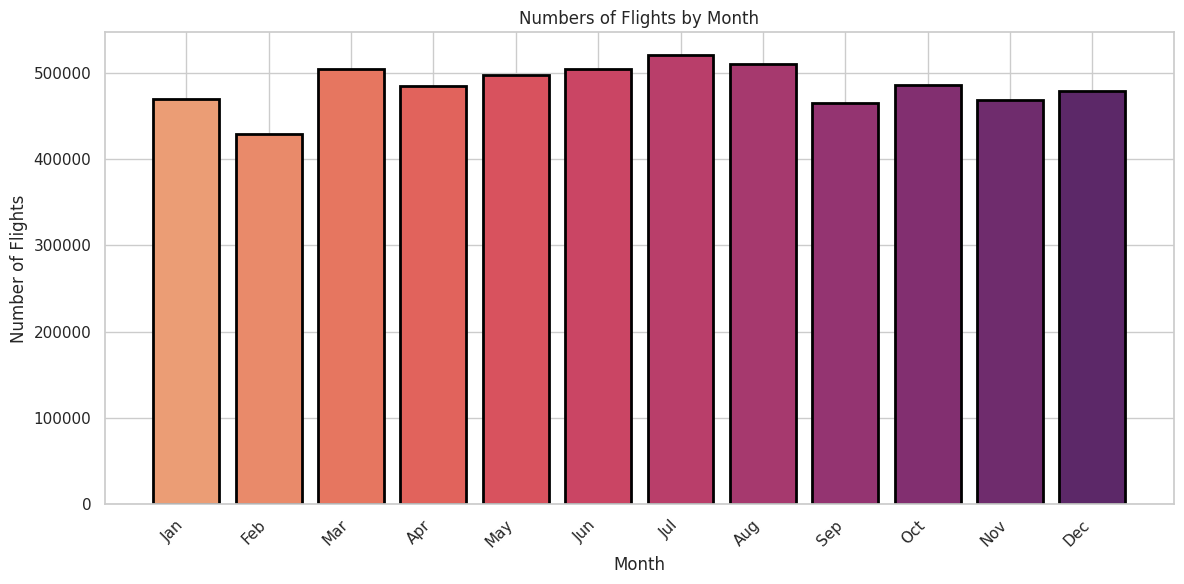

In [10]:
plt.figure(figsize=(12, 6))

# Get current month counts from the DataFrame
current_month_counts = df['MONTH'].value_counts()

# Reindex the series to include all 12 months, filling missing months with 0
month_counts = current_month_counts.reindex(range(1, 13), fill_value=0).sort_index()

color = sns.color_palette("flare", len(month_counts))

plt.bar(month_counts.index, month_counts.values, color=color, edgecolor='black', linewidth=2)
plt.title('Numbers of Flights by Month')
plt.xlabel('Month')
plt.ylabel('Number of Flights')

# Create a list of abbreviated month names
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

# Set x-axis ticks to be the month numbers and labels to be the month names
plt.xticks(month_counts.index, month_names, rotation=45, ha='right') # Rotate for better readability

plt.tight_layout()
plt.show()

**Interpretation: Flights by Month**

This chart reveals monthly flight patterns:
*   **Peak Months:** July and August show the highest flight volumes (summer travel).
*   **Shoulder Months:** March, May, and June also have high activity.
*   **Low Month:** February has the fewest flights.

Overall, flight activity peaks in summer, with a dip in winter.

### 3.4: Numbers of Flights by Day of the Week.

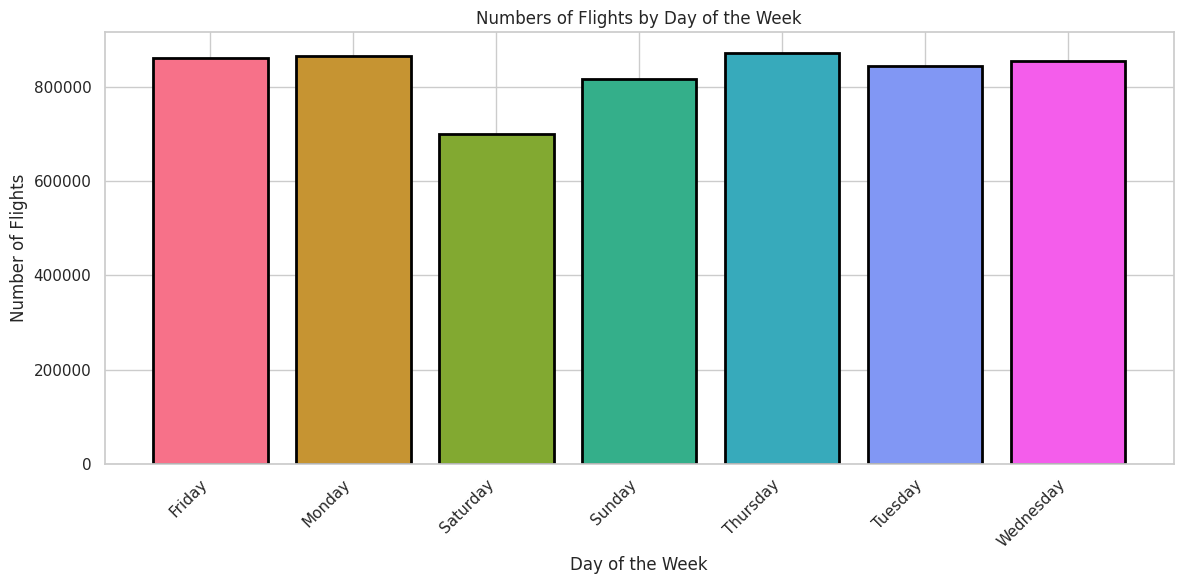

In [11]:
# Bar chat for the number of flights per day
plt.figure(figsize=(12, 6))

week_counts = df['DAY_OF_WEEK_NAME'].value_counts().sort_index()

color = sns.color_palette("husl", len(week_counts))

plt.bar(week_counts.index, week_counts.values, color=color, edgecolor='black', linewidth=2)
plt.title('Numbers of Flights by Day of the Week')
plt.xlabel('Day of the Week')
plt.ylabel('Number of Flights')

plt.xticks(week_counts.index, rotation=45, ha='right')

plt.tight_layout()
plt.show()

 **Interpretation: Flights by Day of Week**

This chart reveals weekly flight patterns:
*   **Busiest Days:** Thursday, Monday, and Friday show the highest flight volumes, indicating peak business and start-of-weekend travel.
*   **Mid-Week Activity:** Tuesday and Wednesday maintain strong, consistent flight activity.
*   **Weekend Trends:** Sunday has significant return travel, while Saturday is typically the quietest day for departures.

Overall, air travel is concentrated on weekdays, with a noticeable dip on Saturdays.

### 3.5: Flights on Weekends vs Weekdays (Donut Chart).

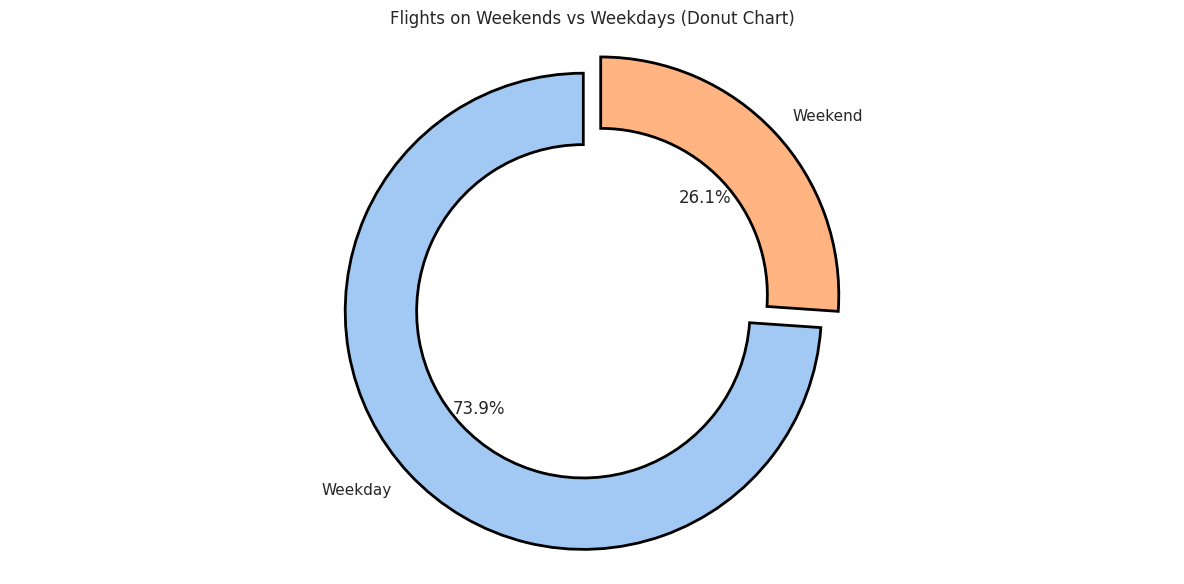

In [12]:
# Donut chart for comparison between flights on weekdays and weekends
plt.figure(figsize=(12, 6))

weekend_counts = df['IS_WEEKEND'].value_counts()
color = sns.color_palette("pastel", len(weekend_counts))

# Create more descriptive labels
descriptive_labels = ['Weekday' if label == False else 'Weekend' for label in weekend_counts.index]


plt.pie(
    weekend_counts.values,
    labels=descriptive_labels,
    autopct='%1.1f%%',
    startangle=90,
    colors=color,
    wedgeprops={'width': 0.3, 'edgecolor': 'black', 'linewidth': 2},
    explode=(0.1, 0) # Apply the explode effect to create a gap
)
plt.title('Flights on Weekends vs Weekdays (Donut Chart)')
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.tight_layout()
plt.show()

**Interpretation: Flights on Weekends vs. Weekdays**

This donut chart shows the proportion of flights by day type:
*   **Weekdays Dominant:** A large majority of flights (approximately 74%) occur on weekdays.
*   **Weekend Travel:** Around 26% of flights happen on weekends.

This indicates significantly higher air travel activity during the working week compared to the weekend.

### 3.6: Flights by Departure Time Block.

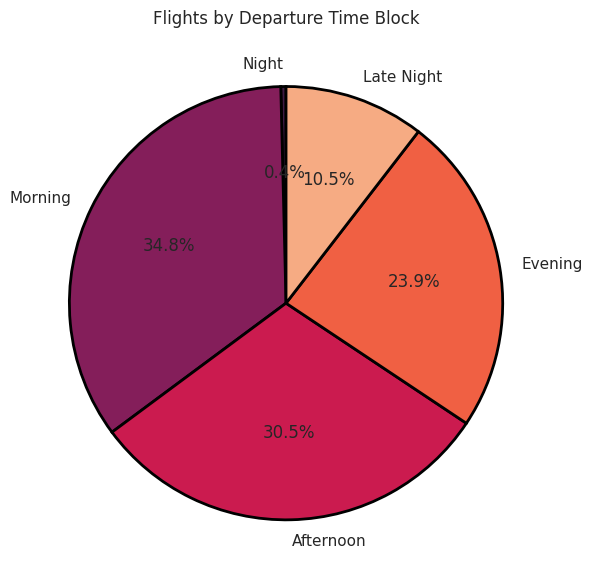

In [13]:
# Pie chart for DEPARTURE_TIME_BLOCK
from datetime import time


plt.figure(figsize=(12, 6))

time_blocks = df['DEPARTURE_TIME_BLOCK'].value_counts().sort_index()

color = sns.color_palette("rocket", len(time_blocks))

plt.pie(
    time_blocks.values,
    labels=time_blocks.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=color,
    wedgeprops={'edgecolor': 'black', 'linewidth': 2}
)
plt.title('Flights by Departure Time Block')
plt.tight_layout()
plt.show()


**Interpretation: Flights by Departure Time Block**

This donut chart illustrates flight distribution across different time blocks:
*   **Peak Hours:** Morning and Afternoon blocks account for the vast majority of flights, indicating high demand during these times.
*   **Evening and Late Night:** These periods have fewer flights but still represent significant activity.
*   **Night:** The 'Night' block has the fewest departures.

Overall, flight operations are heavily concentrated during standard working and daylight hours.

### 3.7: Line plots for DEPARTURE_HOUR and ARRIVAL_HOUR.

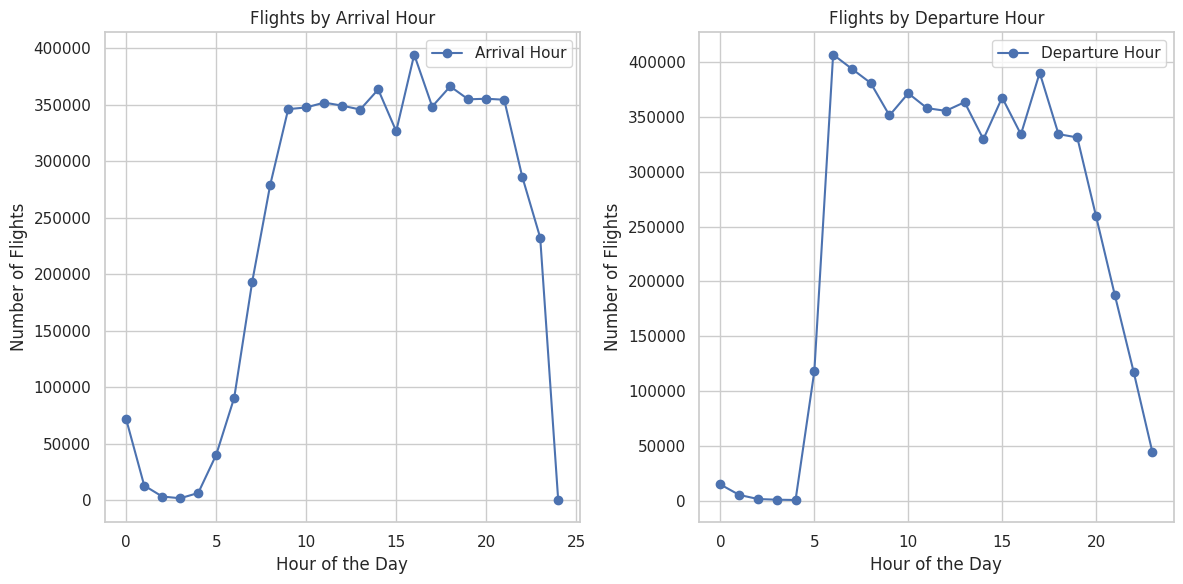

In [14]:
# Line plots for DEPARTURE_HOUR and ARRIVAL_HOUR

plt.figure(figsize=(12, 6))

arrival_hour_counts = df['ARRIVAL_HOUR'].value_counts().sort_index()
departure_hour_counts = df['DEPARTURE_HOUR'].value_counts().sort_index()

# First subplot for Arrival Hour
plt.subplot(1, 2, 1)
plt.plot(arrival_hour_counts.index, arrival_hour_counts.values, label='Arrival Hour', marker='o')
plt.title('Flights by Arrival Hour')
plt.xlabel('Hour of the Day')
plt.ylabel('Number of Flights')
plt.legend()

# Second subplot for Departure Hour
plt.subplot(1, 2, 2)
plt.plot(departure_hour_counts.index, departure_hour_counts.values, label='Departure Hour', marker='o')
plt.title('Flights by Departure Hour')
plt.xlabel('Hour of the Day')
plt.ylabel('Number of Flights')
plt.legend()

plt.tight_layout()
plt.show()

**Interpretation: Flights by Arrival and Departure Hour**

These line plots show the distribution of flights throughout the 24-hour day for both departures and arrivals:

*   **Peak Activity:** Both departures and arrivals show clear peaks during standard working hours, generally from late morning through the evening (e.g., 8 AM - 8 PM), indicating the busiest travel periods.
*   **Early Morning/Late Night:** Flight activity is significantly lower in the very early morning hours (e.g., 1 AM - 5 AM) for both departures and arrivals.
*   **Departure/Arrival Synchronization:** The patterns for departure and arrival hours largely mirror each other, as expected, with flights departing during peak times also arriving during corresponding peak times (allowing for flight duration).

Overall, the plots highlight that air travel is concentrated during the day, with fewer operations during overnight hours.

### 3.8: Top 10 Most Visited Cities.

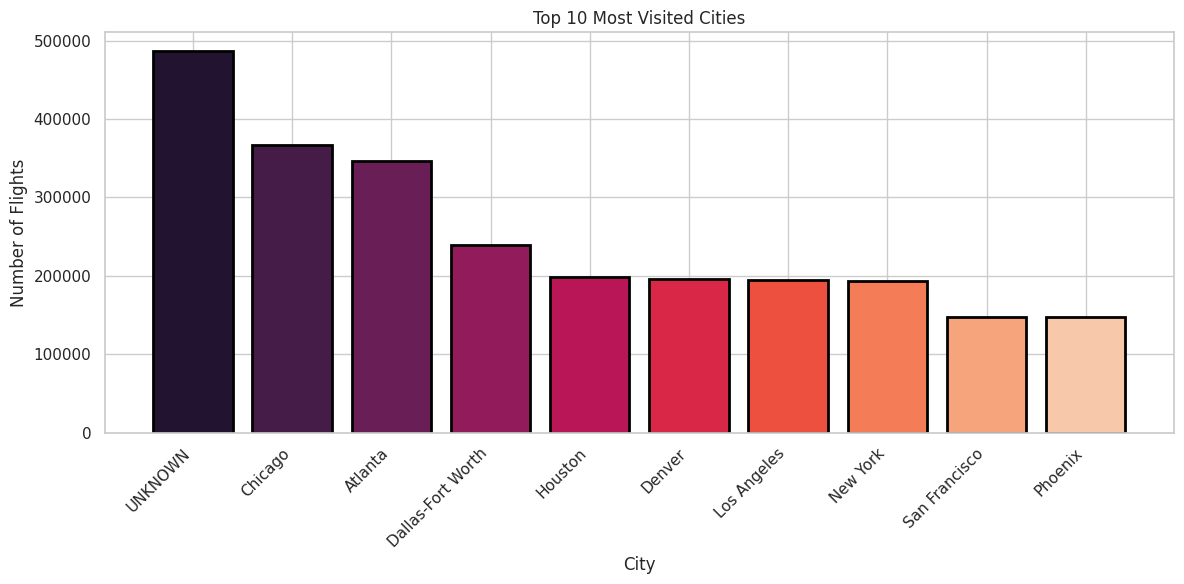

In [15]:
# Bar chart for most visited cities
plt.figure(figsize=(12, 6))

city_counts = df['DESTINATION_CITY'].value_counts().head(10)
color = sns.color_palette("rocket", len(city_counts))

plt.bar(city_counts.index, city_counts.values, color=color, edgecolor='black', linewidth=2)
plt.title('Top 10 Most Visited Cities')
plt.xlabel('City')
plt.ylabel('Number of Flights')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

 **Interpretation: Top 10 Most Visited Cities**

This chart shows the top 10 cities by flight arrivals:
*   **Leading Destinations:** 'UNKNOWN' has the highest count, followed by major hubs like Chicago, Atlanta, and Dallas-Fort Worth.
*   **Key Travel Hubs:** Cities like Houston, Denver, Los Angeles, and New York are also prominent destinations.

This highlights the busiest urban centers and airports in terms of incoming flight traffic.

### 3.9: Plot for flights distributation in airports.

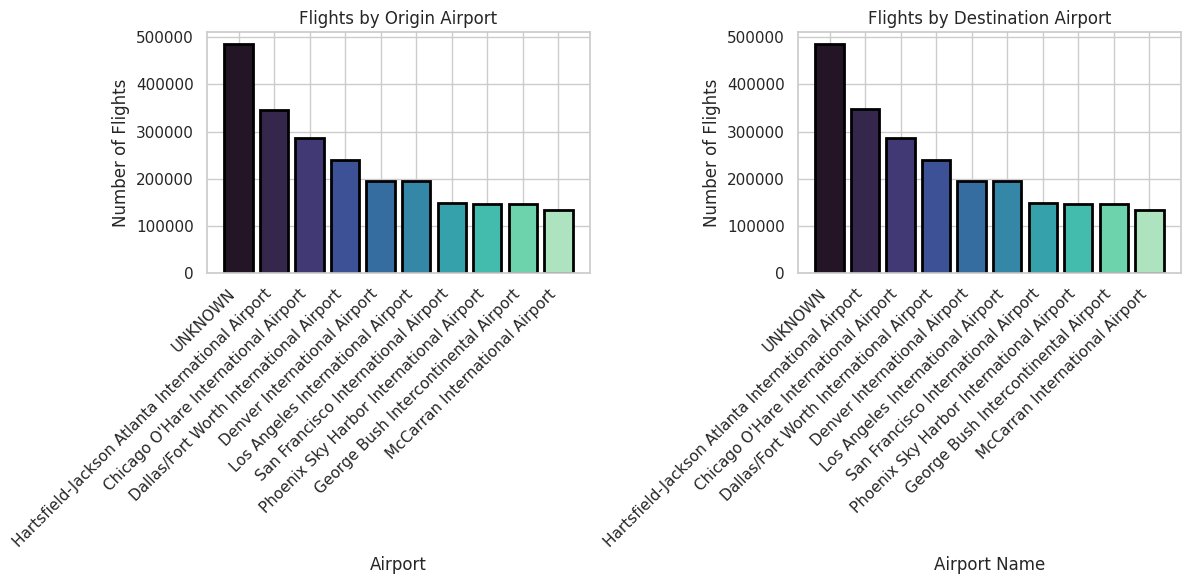

In [16]:
# Plot for flights distributation in airports
plt.figure(figsize=(12, 6))

airport_origin_counts = df['ORIGIN_AIRPORT_NAME'].value_counts().head(10)
airport_destination_counts = df['DESTINATION_AIRPORT_NAME'].value_counts().head(10)

color = sns.color_palette("mako", len(airport_origin_counts))

plt.subplot(1, 2, 1)
plt.bar(airport_origin_counts.index, airport_origin_counts.values, color=color, edgecolor='black', linewidth=2)
plt.title('Flights by Origin Airport')
plt.xlabel('Airport')
plt.ylabel('Number of Flights')
plt.xticks(rotation=45, ha='right')

plt.subplot(1, 2, 2)
plt.bar(airport_destination_counts.index, airport_destination_counts.values, color=color, edgecolor='black', linewidth=2)
plt.title('Flights by Destination Airport')
plt.xlabel('Airport Name')
plt.ylabel('Number of Flights')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

 **Interpretation: Flights by Origin and Destination Airport**

These charts display the top 10 airports for both departures and arrivals:
*   **Leading Airports:** 'UNKNOWN' ranks highest for both, followed by major hubs like Hartsfield-Jackson Atlanta, Chicago O'Hare, and Dallas/Fort Worth International Airports.
*   **Key Hubs:** Denver, Los Angeles, and San Francisco International Airports are also consistently prominent.

These plots highlight the busiest air traffic hubs in terms of both departing and arriving flights.

### 3.10: Comparison of Delayed, and On-Time/Early Flights by Departure Hour.

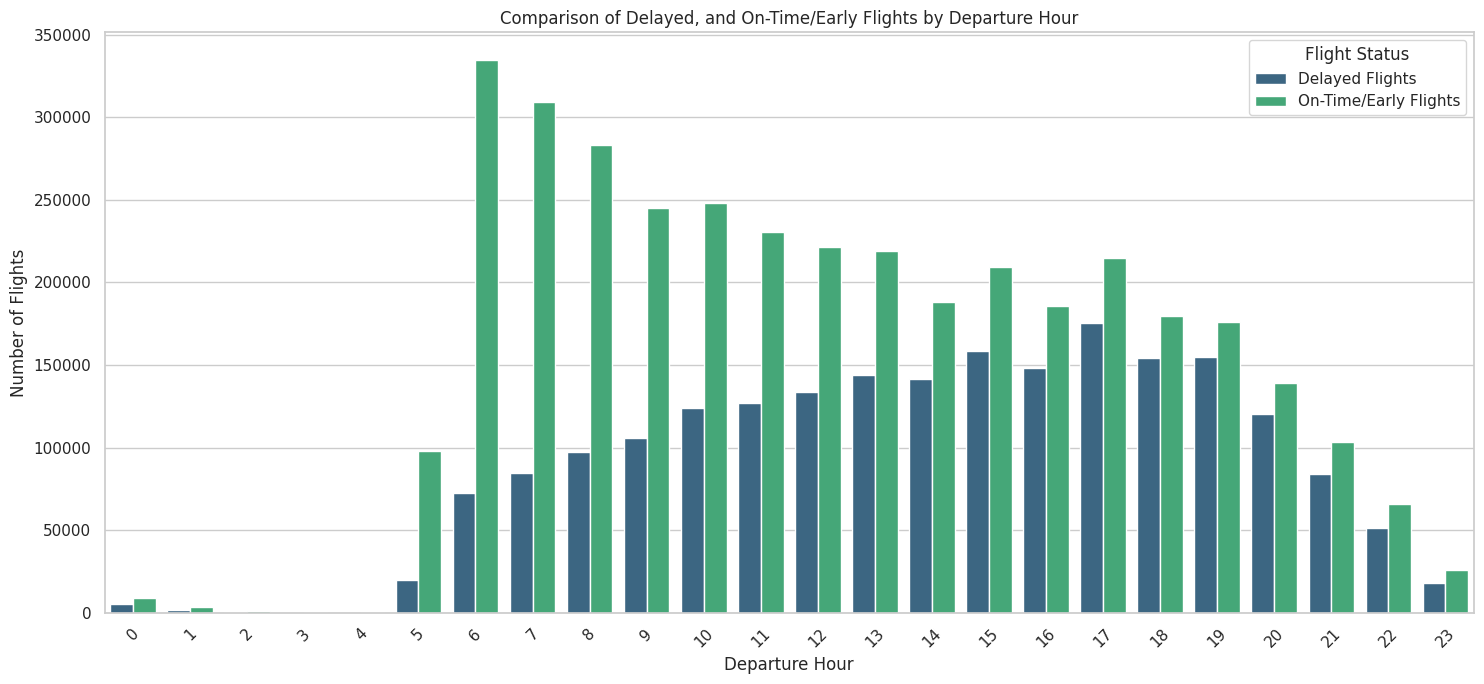

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure all hours from 0 to 23 are present for consistent plotting
all_hours = pd.Series(range(24))

# Delayed flights (DEPARTURE_DELAY > 0) per hour
delayed_flights_by_hour = df[df['DEPARTURE_DELAY'] > 0].groupby('DEPARTURE_HOUR').size().reindex(all_hours, fill_value=0)

# On-time or early flights (DEPARTURE_DELAY <= 0) per hour
on_time_early_flights_by_hour = df[df['DEPARTURE_DELAY'] <= 0].groupby('DEPARTURE_HOUR').size().reindex(all_hours, fill_value=0)

# Combine into a single DataFrame for easier plotting with Seaborn
plot_df = pd.DataFrame({
    'Delayed Flights': delayed_flights_by_hour,
    'On-Time/Early Flights': on_time_early_flights_by_hour
}).reset_index()
plot_df = plot_df.rename(columns={'index': 'Departure Hour'})

# Melt the DataFrame to a long format for Seaborn barplot, which is ideal for grouped bar charts
plot_df_melted = plot_df.melt(id_vars='Departure Hour', var_name='Flight Status', value_name='Number of Flights')

plt.figure(figsize=(15, 7))
sns.barplot(data=plot_df_melted, x='Departure Hour', y='Number of Flights', hue='Flight Status', palette='viridis')
plt.title('Comparison of Delayed, and On-Time/Early Flights by Departure Hour')
plt.xlabel('Departure Hour')
plt.ylabel('Number of Flights')
plt.xticks(rotation=45) # Rotate x-axis labels for better readability
plt.legend(title='Flight Status')
plt.tight_layout()
plt.show()

 **Interpretation: Hourly Flight Status Comparison**

This grouped bar chart compares total, delayed, and on-time/early flights by departure hour:
*   **Peak Delays:** Delays (red bars) are more prominent during afternoon and evening hours, particularly from late morning onwards, often coinciding with peak total flight activity.
*   **On-Time Performance:** Early morning hours (e.g., 0-6 AM) show a higher proportion of on-time/early flights relative to delayed flights.
*   **Evening Congestion:** As the day progresses, especially in the evening, while total flights remain high, the number and proportion of delayed flights also increase.

This highlights that later departure times are generally more susceptible to delays, likely due to cumulative effects throughout the day.

### 3.11: Flight Distance Distribution by Airline.

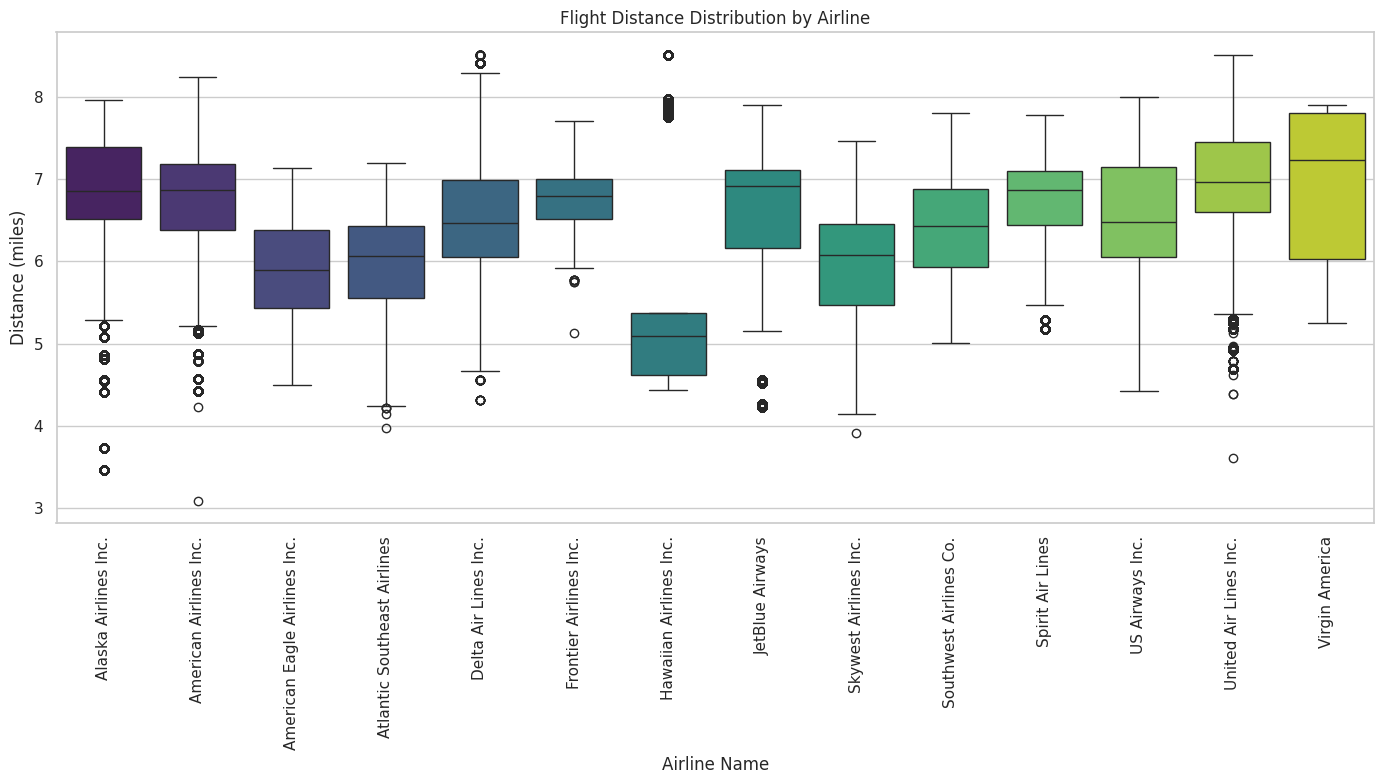

In [18]:
plt.figure(figsize=(14, 8))
sns.boxplot(x='AIRLINE_NAME', y='DISTANCE', data=df, palette='viridis', hue='AIRLINE_NAME', legend=False)
plt.title('Flight Distance Distribution by Airline')
plt.xlabel('Airline Name')
plt.ylabel('Distance (miles)')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

 **Interpretation: Flight Distance Distribution by Airline**

This box plot visualizes flight distances per airline:
*   **Varying Medians:** Some airlines (e.g., Southwest, Skywest) have lower median distances, indicating more short-haul flights.
*   **Long-Haul:** Major carriers (e.g., American, Delta, United) show higher median distances, consistent with their national/international routes.
*   **Outliers:** Many airlines have high-distance outliers, suggesting occasional very long flights.
*   **Specialization:** Some airlines show tighter distributions, indicating specialized route lengths.

#**Week 4:** Delay Analysis – Airline and Weather

* Compare delay causes by airline
* Explore carrier delays, weather delays, NAS delays
* Visualize delays by time of day and airport

In [19]:
df.head()

,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,DEPARTURE_TIME,DEPARTURE_DELAY,TAXI_OUT,WHEELS_OFF,SCHEDULED_TIME,ELAPSED_TIME,AIR_TIME,DISTANCE,WHEELS_ON,TAXI_IN,SCHEDULED_ARRIVAL,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY,AIRLINE_NAME,ORIGIN_AIRPORT_NAME,ORIGIN_CITY,ORIGIN_STATE,ORIGIN_COUNTRY,ORIGIN_LATITUDE,ORIGIN_LONGITUDE,DESTINATION_AIRPORT_NAME,DESTINATION_CITY,DESTINATION_STATE,DESTINATION_COUNTRY,DESTINATION_LATITUDE,DESTINATION_LONGITUDE,DEPARTURE_HOUR,ARRIVAL_HOUR,FLIGHT_DATE,ROUTE,DAY_OF_WEEK_NAME,IS_WEEKEND,DEPARTURE_TIME_BLOCK
0,2015,1,1,4,AS,98,N407AS,ANC,SEA,5,2354.0,-26.194378,3.091043,15.0,5.327876,5.273000,5.135798,7.278629,404.0,1.609438,430,408.0,-42.265583,0,0,NA,0.0,0.0,0.0,0.0,0.0,Alaska Airlines Inc.,Ted Stevens Anchorage International Airport,Anchorage,AK,USA,61.174320,-149.996185,Seattle-Tacoma International Airport,Seattle,WA,USA,47.448978,-122.309311,0,4,2015-01-01,ANC-SEA,Thursday,False,Night
1,2015,1,1,4,AA,2336,N3KUAA,LAX,PBI,10,2.0,-16.863209,2.564949,14.0,5.638355,5.634789,5.575949,7.754053,737.0,1.609438,750,741.0,-14.063154,0,0,NA,0.0,0.0,0.0,0.0,0.0,American Airlines Inc.,Los Angeles International Airport,Los Angeles,CA,USA,33.942539,-118.408073,Palm Beach International Airport,West Palm Beach,FL,USA,26.683161,-80.095589,0,7,2015-01-01,LAX-PBI,Thursday,False,Night
2,2015,1,1,4,US,840,N171US,SFO,CLT,20,18.0,-2.764579,2.833213,34.0,5.659482,5.683580,5.587249,7.739359,800.0,2.484907,806,811.0,3.664161,0,0,NA,0.0,0.0,0.0,0.0,0.0,US Airways Inc.,San Francisco International Airport,San Francisco,CA,USA,37.618999,-122.374840,Charlotte Douglas International Airport,Charlotte,NC,USA,35.214008,-80.943130,0,8,2015-01-01,SFO-CLT,Thursday,False,Night
3,2015,1,1,4,AA,258,N3HYAA,LAX,MIA,20,15.0,-8.938113,2.772589,30.0,5.655992,5.641907,5.556828,7.759187,748.0,2.197225,805,756.0,-14.063154,0,0,NA,0.0,0.0,0.0,0.0,0.0,American Airlines Inc.,Los Angeles International Airport,Los Angeles,CA,USA,33.942539,-118.408073,Miami International Airport,Miami,FL,USA,25.793249,-80.290558,0,8,2015-01-01,LAX-MIA,Thursday,False,Night
4,2015,1,1,4,AS,135,N527AS,SEA,ANC,25,24.0,-1.210559,2.484907,35.0,5.463832,5.375278,5.298317,7.278629,254.0,1.791759,320,259.0,-39.887878,0,0,NA,0.0,0.0,0.0,0.0,0.0,Alaska Airlines Inc.,Seattle-Tacoma International Airport,Seattle,WA,USA,47.448978,-122.309311,Ted Stevens Anchorage International Airport,Anchorage,AK,USA,61.174320,-149.996185,0,3,2015-01-01,SEA-ANC,Thursday,False,Night


## Step 4: Compare delay causes.

### 4.1: Delay Percentage.

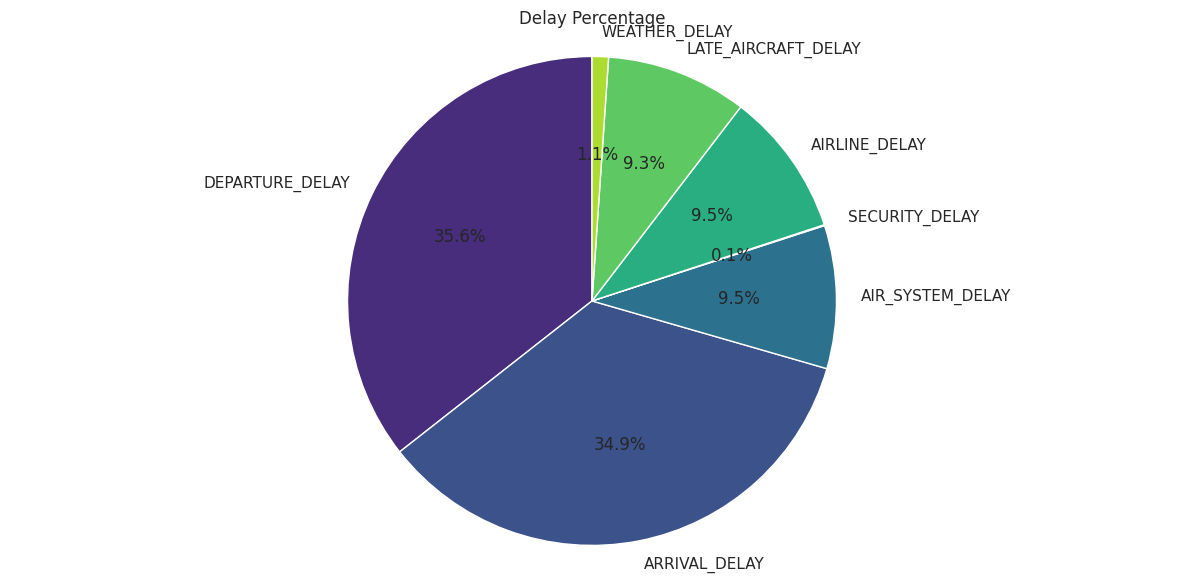

In [20]:
# Plot for Delay percentage
plt.figure(figsize=(12, 6))
delay_col = ['DEPARTURE_DELAY', 'ARRIVAL_DELAY', 'AIR_SYSTEM_DELAY', 'SECURITY_DELAY', 'AIRLINE_DELAY', 'LATE_AIRCRAFT_DELAY', 'WEATHER_DELAY']
delay_percentage = {}
for col in delay_col:
    delay_percentage[col] = (df[col][df[col] > 0].count() / df[col].count()) * 100

color = sns.color_palette("viridis", len(delay_percentage))

plt.pie(delay_percentage.values(), labels=delay_percentage.keys(), autopct='%1.1f%%', startangle=90, colors=color)
plt.title('Delay Percentage')
plt.axis('equal')
plt.tight_layout()
plt.show()

**Interpretation: Delay Percentage**

This pie chart shows the distribution of different delay types:
*   **Leading Delays:** Departure and Arrival delays are the most frequent.
*   **Other Significant Factors:** Airline, Air System, and Late Aircraft delays also contribute considerably.
*   **Minor Causes:** Security and Weather delays account for a much smaller percentage.

### 4.2: Delay Causes by Airline(carrier delays)

/tmp/ipython-input-2742898048.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  delay_summary = df.groupby('AIRLINE_NAME')[delay_cause_cols].sum().reset_index()


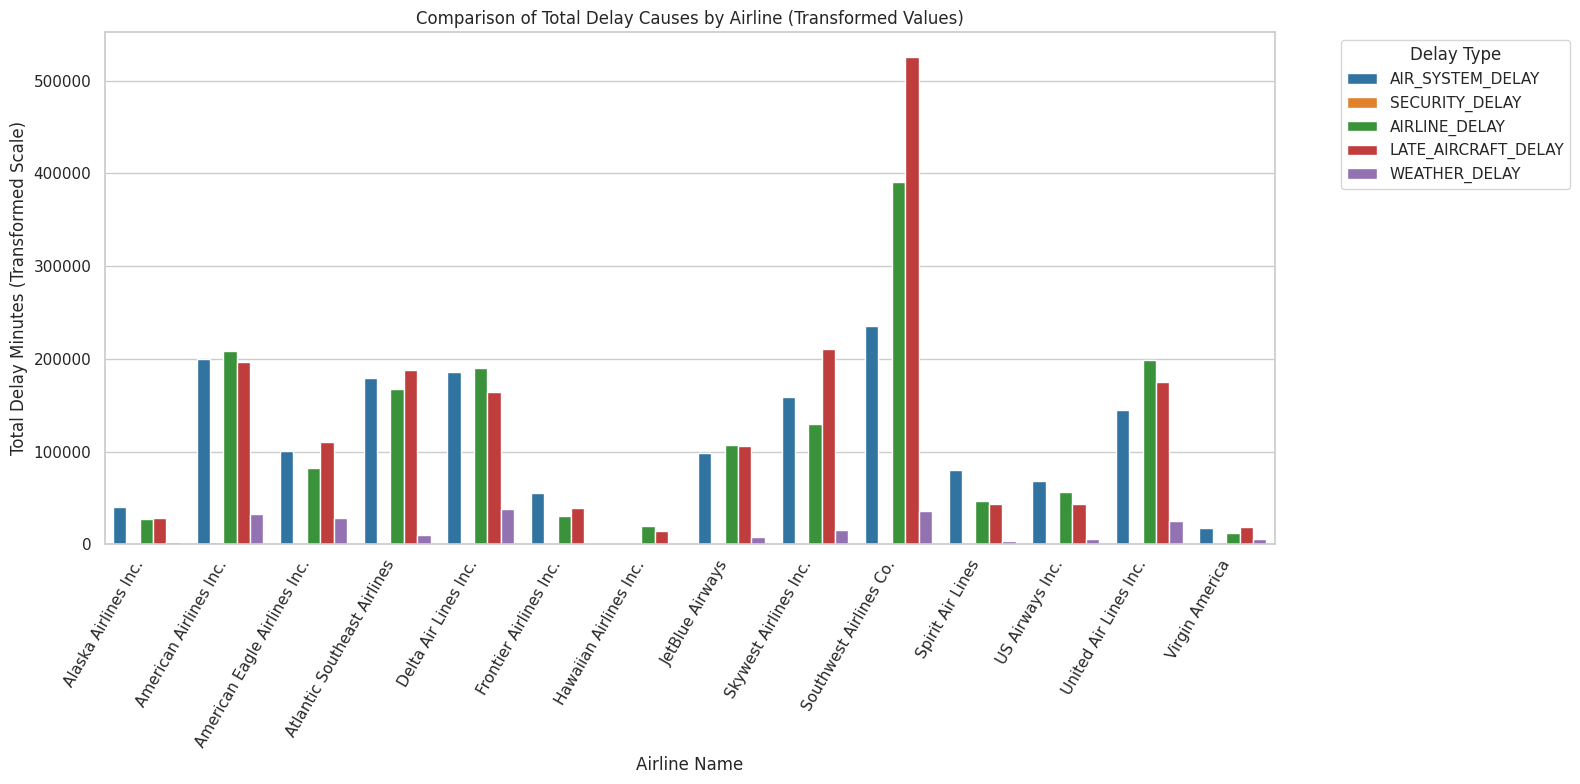

In [21]:
# delay columns we want to analyze
delay_cause_cols = [
    'AIR_SYSTEM_DELAY',
    'SECURITY_DELAY',
    'AIRLINE_DELAY',
    'LATE_AIRCRAFT_DELAY',
    'WEATHER_DELAY'
]

# Filter out flights with no delays for these categories to get meaningful sums
# And only consider rows where at least one of these specific delays is greater than 0
# or sum up all delays greater than 0 from the original dataframe.
# For visualization, it's better to sum up the actual delay minutes for each type.

# Calculate the sum of each delay type for each airline
# We'll consider a delay if the value is > 0 in the transformed data.
# The transformed values still maintain the relative magnitude of delays.

delay_summary = df.groupby('AIRLINE_NAME')[delay_cause_cols].sum().reset_index()

# Melt the DataFrame to long format for Seaborn barplot
# This stacks the delay types for each airline into a single column
delay_summary_melted = delay_summary.melt(
    id_vars='AIRLINE_NAME',
    value_vars=delay_cause_cols,
    var_name='Delay Type',
    value_name='Total Delay Minutes (Transformed)'
)

plt.figure(figsize=(16, 8))
sns.barplot(
    data=delay_summary_melted,
    x='AIRLINE_NAME',
    y='Total Delay Minutes (Transformed)',
    hue='Delay Type',
    palette='tab10' # A good palette for categorical data
)
plt.title('Comparison of Total Delay Causes by Airline (Transformed Values)')
plt.xlabel('Airline Name')
plt.ylabel('Total Delay Minutes (Transformed Scale)')
plt.xticks(rotation=60, ha='right') # Rotate for better readability
plt.legend(title='Delay Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

**Interpretation: Comparison of Delay Causes by Airline**

This grouped bar chart shows the total transformed delay minutes for different causes across airlines:
*   **Airline and Late Aircraft Delays:** These are often the largest contributors, indicating internal operational issues or cascading delays.
*   **Air System Delays:** Also significant, these point to air traffic control, congestion, or other system-wide issues.
*   **Weather and Security Delays:** Generally have a smaller impact but can be severe when they occur.

Overall, the chart highlights which airlines are more affected by specific types of delays.

### 4.3: Weather Delay by Month

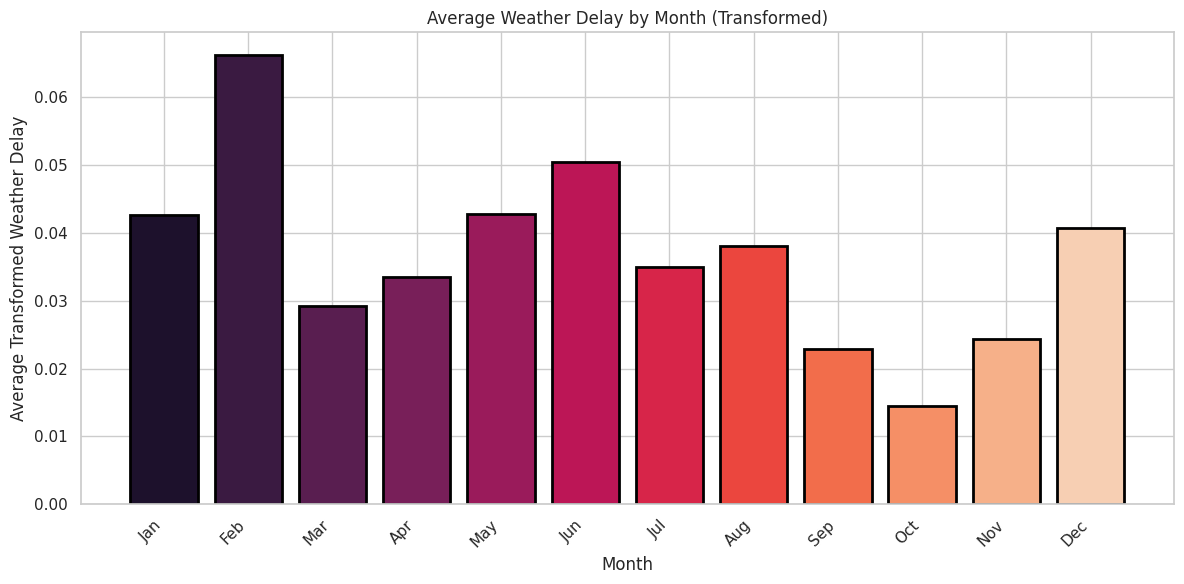

In [28]:
# Plot average weather delay by month
plt.figure(figsize=(12, 6))

# Calculate the average weather delay for each month
# Using the transformed 'WEATHER_DELAY' column
weather_delay_by_month = df.groupby('MONTH')['WEATHER_DELAY'].mean().reindex(range(1, 13), fill_value=0).sort_index()

# Create a list of abbreviated month names for better x-axis labels
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

color = sns.color_palette("rocket", len(weather_delay_by_month))

plt.bar(
    weather_delay_by_month.index,
    weather_delay_by_month.values,
    color=color,
    edgecolor='black',
    linewidth=2
)
plt.title('Average Weather Delay by Month (Transformed)')
plt.xlabel('Month')
plt.ylabel('Average Transformed Weather Delay')
plt.xticks(weather_delay_by_month.index, month_names, rotation=45, ha='right') # Set month names as x-axis labels
plt.tight_layout()
plt.show()

**Interpretation: Average Weather Delay by Month**

This chart illustrates the average impact of weather on flight delays across months:
*   **Strategic Planning:** February and June exhibit the highest average weather delays. Businesses (airlines, logistics, travel agencies) should anticipate and plan for increased disruptions during these months, potentially adjusting schedules or increasing buffer times.
*   **Operational Efficiency:** October and September show the lowest average weather delays. These periods present opportunities for maximizing operational efficiency and on-time performance, potentially by scheduling more critical or time-sensitive flights during these months.
*   **Risk Management:** Understanding these seasonal patterns allows for proactive risk management, such as deploying additional resources for de-icing in winter months or enhancing weather monitoring capabilities during storm seasons. This can lead to improved customer satisfaction and reduced operational costs from cascading delays.

### 4.4: Total NAS (Air System) Delays by Airline

/tmp/ipython-input-3377306681.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  nas_delay_by_airline = df.groupby('AIRLINE_NAME')['AIR_SYSTEM_DELAY'].sum().sort_values(ascending=False).reset_index()
/tmp/ipython-input-3377306681.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


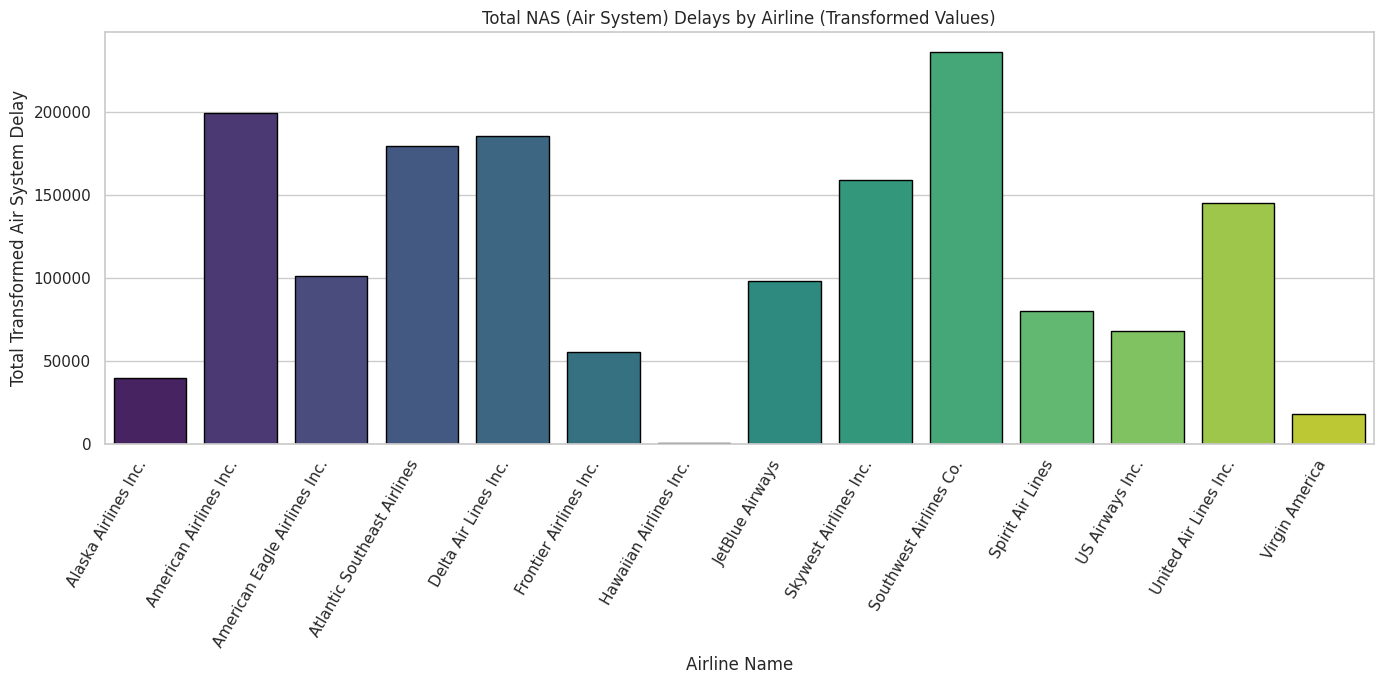

In [30]:
plt.figure(figsize=(14, 7))

# Calculate total AIR_SYSTEM_DELAY for each airline
nas_delay_by_airline = df.groupby('AIRLINE_NAME')['AIR_SYSTEM_DELAY'].sum().sort_values(ascending=False).reset_index()

color = sns.color_palette("viridis", len(nas_delay_by_airline))

sns.barplot(
    data=nas_delay_by_airline,
    x='AIRLINE_NAME',
    y='AIR_SYSTEM_DELAY',
    palette=color,
    edgecolor='black',
    linewidth=1
)
plt.title('Total NAS (Air System) Delays by Airline (Transformed Values)')
plt.xlabel('Airline Name')
plt.ylabel('Total Transformed Air System Delay')
plt.xticks(rotation=60, ha='right')
plt.tight_layout()
plt.show()

 **Interpretation: Total NAS (Air System) Delays by Airline**

This bar chart illustrates the total transformed minutes of NAS (Air System) delays experienced by each airline:
*   **Major Impact:** Airlines like American Airlines Inc., Delta Air Lines Inc., and Southwest Airlines Co. show the highest total NAS delays. This could be due to their larger flight volumes and extensive network operations.
*   **Proportionality:** While larger airlines naturally accumulate more total delay minutes, this plot helps identify which carriers face the most disruption from air traffic control, airport congestion, and other system-related issues.
*   **Operational Planning:** For airlines, this data can inform strategic decisions on scheduling, hub management, and advocacy for infrastructure improvements within the National Airspace System to mitigate system-wide delays.

### 4.5: Delays time of day(Departure Hour)

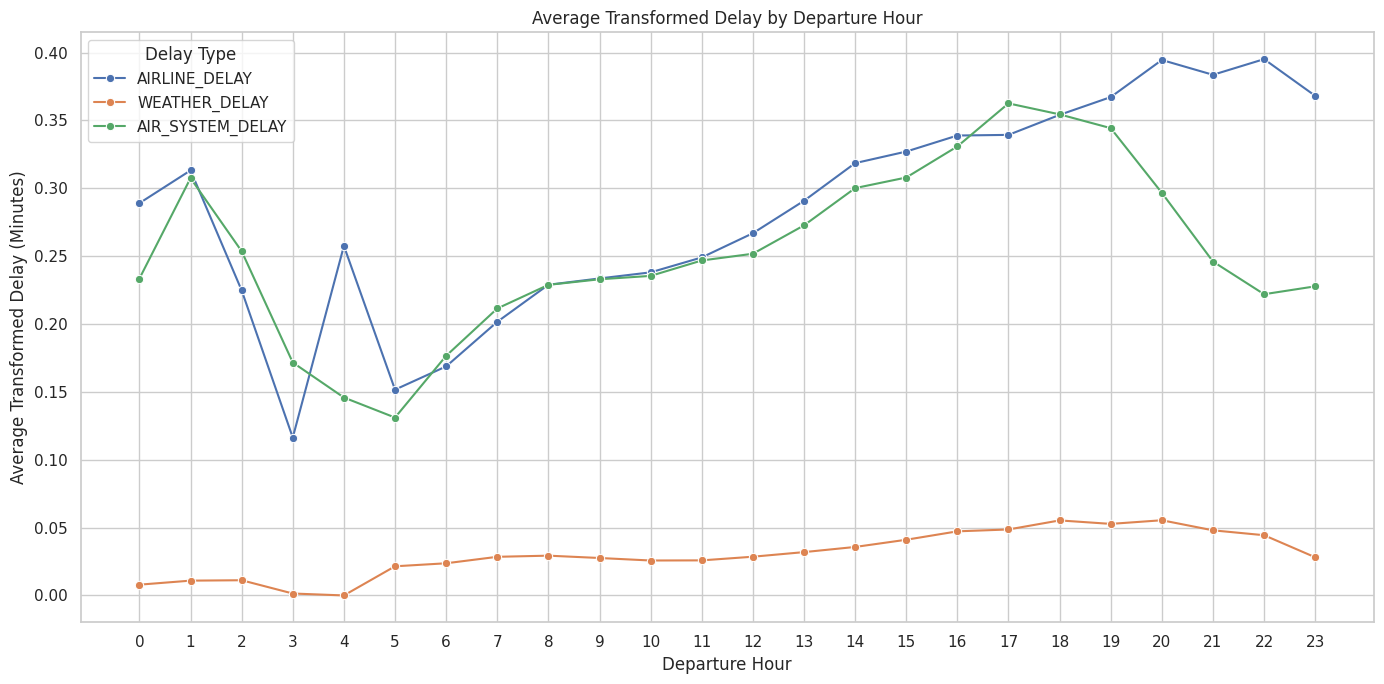

In [22]:
delay_causes = ['AIRLINE_DELAY', 'WEATHER_DELAY', 'AIR_SYSTEM_DELAY']

# Group by DEPARTURE_HOUR and calculate the mean of each delay type
delay_by_hour = df.groupby('DEPARTURE_HOUR')[delay_causes].mean().reset_index()

# Melt the DataFrame to long format for easier plotting with Seaborn
delay_by_hour_melted = delay_by_hour.melt(id_vars='DEPARTURE_HOUR', var_name='Delay Type', value_name='Average Transformed Delay')

plt.figure(figsize=(14, 7))
sns.lineplot(data=delay_by_hour_melted, x='DEPARTURE_HOUR', y='Average Transformed Delay', hue='Delay Type', marker='o')
plt.title('Average Transformed Delay by Departure Hour')
plt.xlabel('Departure Hour')
plt.ylabel('Average Transformed Delay (Minutes)')
plt.xticks(range(0, 24)) # Ensure all hours are shown on the x-axis
plt.grid(True)
plt.legend(title='Delay Type')
plt.tight_layout()
plt.show()

**Interpretation: Average Delay by Departure Hour**

This line plot shows how average delays evolve throughout the day:
*   **Morning Efficiency:** Early morning flights (0-6 AM) consistently experience the lowest average delays across all types. This indicates a window of higher operational efficiency.
*   **Cumulative Delays:** Delays generally increase as the day progresses, peaking in the late afternoon/early evening. This suggests a cumulative effect, where initial disruptions cascade throughout the schedule.
*   **Key Insight:** Prioritizing critical flights or optimizing operations during early morning hours could significantly reduce overall delay impact, while strategic planning is needed to manage the higher delay risks in later time blocks.

### 4.6: Delays by Origin Airport

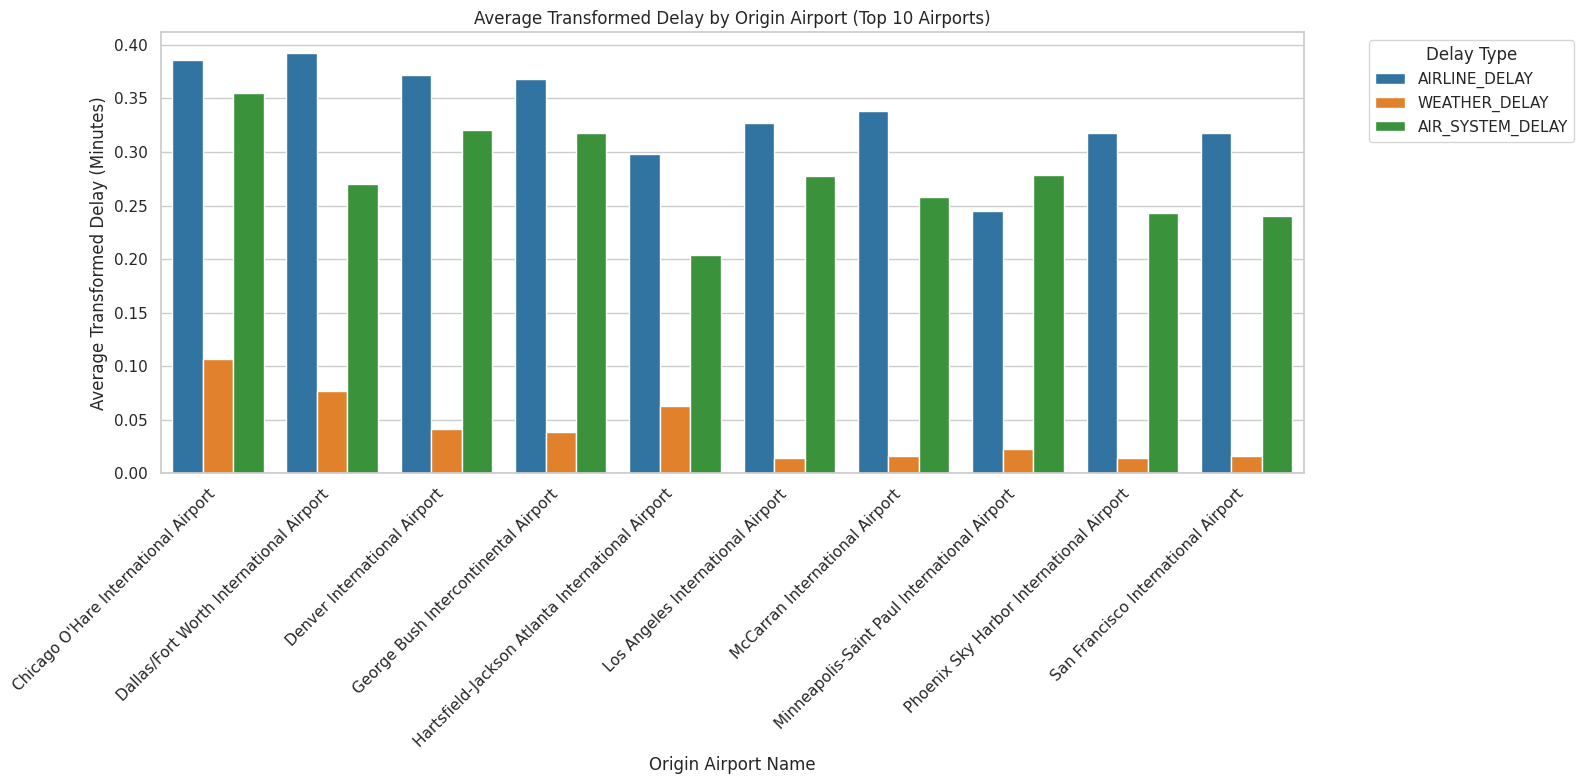

In [23]:
N = 10 # Define the number of top airports to visualize

# 1. Identify the top N origin airports based on the total number of flights, EXCLUDING 'UNKNOWN'
top_origin_airports_raw = df['ORIGIN_AIRPORT_NAME'].value_counts()
top_origin_airports = top_origin_airports_raw[top_origin_airports_raw.index != 'UNKNOWN'].head(N).index

# 2. Filter the DataFrame to include only flights from these top N airports
df_top_airports = df[df['ORIGIN_AIRPORT_NAME'].isin(top_origin_airports)].copy()

# Convert the 'ORIGIN_AIRPORT_NAME' column to string to ensure groupby only considers actual airports present
df_top_airports['ORIGIN_AIRPORT_NAME'] = df_top_airports['ORIGIN_AIRPORT_NAME'].astype(str)

# 3. Group the filtered DataFrame by 'ORIGIN_AIRPORT_NAME' and calculate the mean of delay types
delay_causes = ['AIRLINE_DELAY', 'WEATHER_DELAY', 'AIR_SYSTEM_DELAY']
# observed=True is not needed when the column is converted to string
delay_by_airport = df_top_airports.groupby('ORIGIN_AIRPORT_NAME')[delay_causes].mean().reset_index()

# Melt the DataFrame to long format for easier plotting with Seaborn
delay_by_airport_melted = delay_by_airport.melt(id_vars='ORIGIN_AIRPORT_NAME', var_name='Delay Type', value_name='Average Transformed Delay')

# 4. Create a grouped bar chart
plt.figure(figsize=(16, 8))
sns.barplot(data=delay_by_airport_melted, x='ORIGIN_AIRPORT_NAME', y='Average Transformed Delay', hue='Delay Type', palette='tab10')

# 5. Label the axes and add a title and legend for clarity
plt.title(f'Average Transformed Delay by Origin Airport (Top {N} Airports)')
plt.xlabel('Origin Airport Name')
plt.ylabel('Average Transformed Delay (Minutes)')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Delay Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

 **Interpretation: Average Delays by Origin Airport**

This chart reveals how different origin airports contribute to airline, weather, and air system delays:
*   **Operational Hotspots:** Some airports exhibit consistently higher average delays across all categories, indicating persistent operational challenges. Identifying these 'hotspots' is crucial for targeted interventions.
*   **Delay Type Dominance:** In many major hubs, 'Air System Delay' is a significant factor, suggesting that air traffic control and airport infrastructure capacity are key bottlenecks. Conversely, 'Airline Delay' often highlights internal operational inefficiencies specific to carriers.
*   **Resource Allocation:** Understanding these airport-specific delay profiles can inform strategic resource allocation, such as deploying additional ground staff, investing in air traffic control technology, or adjusting flight schedules to mitigate peak delay times at certain locations.
*   **Carrier Performance:** Airlines can use this data to benchmark their performance at different airports and identify where their operations are most susceptible to disruption, allowing for focused improvement efforts.